1. From scratch

Create:

X = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

Train a Linear Regression model using sklearn.

Tasks:

Create X and y
Reshape X
Fit the model
Find the coefficient
Find the intercept
Predict y for x = 6

In [113]:
#import
from sklearn.linear_model import LinearRegression

#Create X and y
X = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

#Reshape X
X=[[1], [2], [3], [4], [5]]

#Fit the model
model=LinearRegression()
model.fit(X,y)

#Find the coefficient
print(f"coefficient:",model.coef_)

#Find the intercept
print(f"intercept:",model.intercept_)

#Predict y for x = 6
y_pred=model.predict([[6]])
print(f"prediction:",y_pred)

coefficient: [2.]
intercept: 0.0
prediction: [12.]


2. House price prediction

Dataset:

Area (sqft) 	Price (lakhs)
500	                 20
700	                 28
900	                 36
1100	             45
1300	             53

Build a Linear Regression model.

Find:

coefficient
intercept
prediction for 1500 sqft
MAE
MSE
RMSE
R²

In [114]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [115]:
# 1. Create data
X = np.array([500, 700, 900, 1100, 1300]).reshape(-1, 1)
y = np.array([20, 28, 36, 45, 53])

In [116]:
model=LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.04]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.95
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[632.46]


In [117]:
#Find the coefficient
print(f"coefficient:",model.coef_[0])

#Find the intercept
print(f"intercept:",model.intercept_)

coefficient: 0.041499999999999974
intercept: -0.9499999999999815


In [118]:
#prediction for 1500 sqft
y_pred = model.predict(X)
new_pred=model.predict([[1500]])
print(f"prediction for 1500 sqft:",new_pred[0])

prediction for 1500 sqft: 61.29999999999998


In [119]:
#metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y,y_pred)
mse = mean_squared_error(y,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 0.20000000000000426
MSE: 0.06000000000000085
RMSE: 0.24494897427831955
R2: 0.9995647127103888


3. Train/test split

Use the same dataset.

Split it into 80% training and 20% testing.
Train Linear Regression.
Predict on test data.
Calculate:
MAE
MSE
RMSE
R²

Question: Why can the test score be different from the training score?

In [120]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [121]:
# 1. Create data
X = np.array([500, 700, 900, 1100, 1300]).reshape(-1, 1)
y = np.array([20, 28, 36, 45, 53])


In [122]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [123]:
model =LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


In [124]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [125]:
print("X_train:", X_train)
print("X_test:", X_test)
print("y_train:", y_train)
print("y_test:", y_test)

print("Predictions:", y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

X_train: [[1300]
 [ 900]
 [ 500]
 [1100]]
X_test: [[700]]
y_train: [53 36 20 45]
y_test: [28]
Predictions: [28.14285714]
MAE: 0.14285714285714235
MSE: 0.02040816326530598
RMSE: 0.14285714285714235
R²: nan


## Hands-On Example: Logistic Regression with Scikit-Learn

We'll use the Breast Cancer dataset (built into scikit-learn) — a binary classification problem: predict if a tumor is malignant (0) or benign (1).

## 1. Import libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, RocCurveDisplay
)


## 2. Load dataset

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target

## 3. Train-test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

## 4. Feature scaling (important for logistic regression!)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Train the model

In [6]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

## 6. Predictions

In [7]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## 7. Evaluate metrics

In [8]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9649122807017544
Precision: 0.9722222222222222
Recall   : 0.9722222222222222
F1 Score : 0.9722222222222222
ROC-AUC  : 0.9966931216931217


##  8. Confusion Matrix Plot

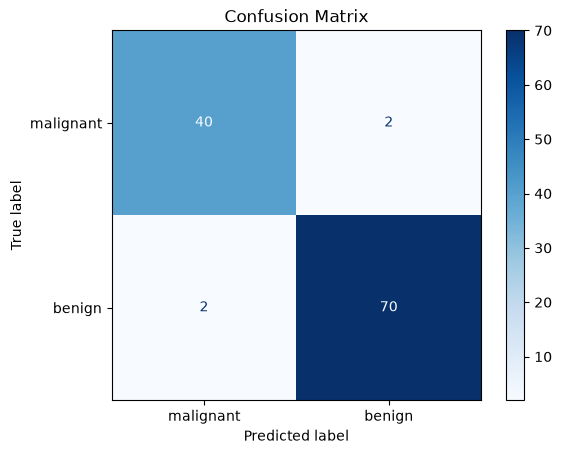

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## 9. ROC Curve Plot

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

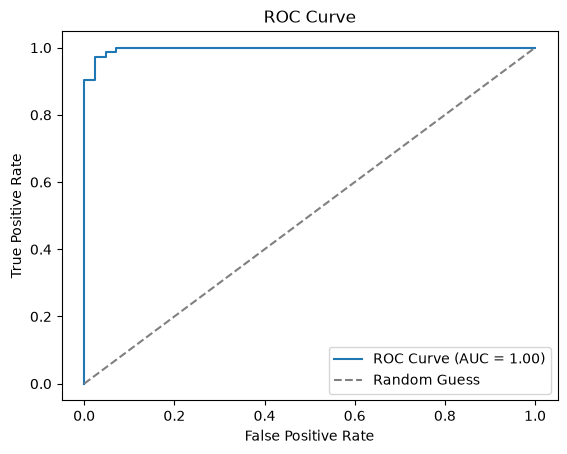

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Interpretation:

The model is highly accurate (~97%) — expected since this dataset is well-separated.
ROC-AUC close to 1.0 shows the model separates malignant vs. benign cases very well.
The confusion matrix will show very few false negatives (missed malignant cases) — critical in medical contexts.

## Practice with Code (using the Iris dataset — 3 classes)

## STEP 0: Imports

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score
)
from sklearn.metrics import accuracy_score, classification_report

## STEP 1: Load data (Iris has 3 classes: setosa, versicolor, virginica)

In [3]:
data = load_iris()
X, y = data.data, data.target
print("Classes:", data.target_names)
print("Class counts:", np.bincount(y))

Classes: ['setosa' 'versicolor' 'virginica']
Class counts: [50 50 50]


## STEP 2: THE PROBLEM — single split gives unstable results

In [4]:
print("\n--- Single split, different random states ---")
for seed in [0, 1, 2, 3, 4]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"random_state={seed} -> accuracy={acc:.4f}")


--- Single split, different random states ---
random_state=0 -> accuracy=1.0000
random_state=1 -> accuracy=0.9667
random_state=2 -> accuracy=1.0000
random_state=3 -> accuracy=0.9000
random_state=4 -> accuracy=1.0000


## STEP 3: Train / Validation / Test split (3-way)

In [8]:
# First split off the test set (locked away, touched once)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# Now split remaining into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [11]:
print(f"\nTrain size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")



Train size: 90, Val size: 30, Test size: 30


In [12]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
val_acc = accuracy_score(y_val, model.predict(X_val))
print(f"Validation accuracy: {val_acc:.4f}")


Validation accuracy: 0.9333


In [13]:
# ... you'd tune hyperparameters here using validation set ...
test_acc = accuracy_score(y_test, model.predict(X_test))
print(f"FINAL test accuracy (touched once): {test_acc:.4f}")

FINAL test accuracy (touched once): 0.9667


## STEP 4: K-Fold Cross-Validation (plain)

In [ ]:

print("\n--- Plain K-Fold (K=5) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=200)
scores_kf = cross_val_score(model, X, y, cv=kf)
print("Fold scores:", np.round(scores_kf, 4))
print(f"Mean: {scores_kf.mean():.4f}  |  Std (variance across folds): {scores_kf.std():.4f}")



--- Plain K-Fold (K=5) ---
Fold scores: [1.     1.     0.9333 0.9667 0.9667]
Mean: 0.9733  |  Std (variance across folds): 0.0249


## STEP 5: Stratified K-Fold (better for classification)

In [ ]:

print("\n--- Stratified K-Fold (K=5) ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(model, X, y, cv=skf)
print("Fold scores:", np.round(scores_skf, 4))
print(f"Mean: {scores_skf.mean():.4f}  |  Std (variance across folds): {scores_skf.std():.4f}")
# Compare std of KFold vs StratifiedKFold -- stratified is usually more stable


--- Stratified K-Fold (K=5) ---
Fold scores: [1.     0.9667 0.9333 1.     0.9333]
Mean: 0.9667  |  Std (variance across folds): 0.0298


## STEP 6: Multiclass strategies -- One-vs-Rest vs One-vs-One

In [ ]:

print("\n--- One-vs-Rest (OvR) ---")
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=200))
scores_ovr = cross_val_score(ovr_model, X, y, cv=skf)
print("Fold scores:", np.round(scores_ovr, 4))
print(f"Mean: {scores_ovr.mean():.4f}  |  Std: {scores_ovr.std():.4f}")


--- One-vs-Rest (OvR) ---
Fold scores: [0.9333 0.9667 0.9    1.     0.9333]
Mean: 0.9467  |  Std: 0.0340


In [17]:
print("\n--- One-vs-One (OvO) ---")
ovo_model = OneVsOneClassifier(LogisticRegression(max_iter=200))
scores_ovo = cross_val_score(ovo_model, X, y, cv=skf)
print("Fold scores:", np.round(scores_ovo, 4))
print(f"Mean: {scores_ovo.mean():.4f}  |  Std: {scores_ovo.std():.4f}")


--- One-vs-One (OvO) ---
Fold scores: [1.     0.9667 0.9333 1.     0.9667]
Mean: 0.9733  |  Std: 0.0249


## STEP 7: Native multinomial Logistic Regression (softmax, no OvR/OvO needed)

In [20]:
print("\n--- Native multinomial LogisticRegression ---")
multi_model = LogisticRegression(max_iter=200, solver='lbfgs')   
scores_multi = cross_val_score(multi_model, X, y, cv=skf)
print("Fold scores:", np.round(scores_multi, 4))
print(f"Mean: {scores_multi.mean():.4f}  |  Std: {scores_multi.std():.4f}")



--- Native multinomial LogisticRegression ---
Fold scores: [1.     0.9667 0.9333 1.     0.9333]
Mean: 0.9667  |  Std: 0.0298


## STEP 8: Final comparison table

In [21]:
print("\n=== COMPARISON: Mean accuracy & Fold-to-Fold Std ===")
results = {
    "Plain KFold":            (scores_kf.mean(), scores_kf.std()),
    "Stratified KFold":       (scores_skf.mean(), scores_skf.std()),
    "One-vs-Rest":            (scores_ovr.mean(), scores_ovr.std()),
    "One-vs-One":             (scores_ovo.mean(), scores_ovo.std()),
    "Multinomial (softmax)":  (scores_multi.mean(), scores_multi.std()),
}
df_results = pd.DataFrame(results, index=["Mean Accuracy", "Std (variance)"]).T
print(df_results.round(4))


=== COMPARISON: Mean accuracy & Fold-to-Fold Std ===
                       Mean Accuracy  Std (variance)
Plain KFold                   0.9733          0.0249
Stratified KFold              0.9667          0.0298
One-vs-Rest                   0.9467          0.0340
One-vs-One                    0.9733          0.0249
Multinomial (softmax)         0.9667          0.0298
